# Rossmann Store Sales - Demand Forecasting

Using the Rossmann dataset from Kaggle (1M+ rows, 1,115 stores across Germany). The goal is to forecast daily sales and see how much better XGBoost does vs a simple rolling average baseline. Also threw in ARIMA on one store for comparison, and some segmentation analysis at the end.

Dataset: https://www.kaggle.com/competitions/rossmann-store-sales/data

In [1]:
!pip install xgboost statsmodels -q

In [2]:
import os
import io
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
from google.colab import files
import io

if 'uploaded' not in dir() or not uploaded:
    uploaded = files.upload()

train_key = [k for k in uploaded.keys() if 'train' in k.lower()][-1]
store_key = [k for k in uploaded.keys() if 'store' in k.lower()][0]
print(f'loaded: {train_key}, {store_key}')

Saving train 2.csv to train 2.csv
Saving train.csv to train.csv
Saving store.csv to store.csv
loaded: train.csv, store.csv


In [4]:
train = pd.read_csv(io.BytesIO(uploaded[train_key]), low_memory=False, parse_dates=['Date'])
store = pd.read_csv(io.BytesIO(uploaded[store_key]))

print(train.shape, store.shape)
print(train['Date'].min(), train['Date'].max())
train.head()

(1017209, 9) (1115, 10)
2013-01-01 00:00:00 2015-07-31 00:00:00


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


<!-- -->

In [5]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


<!-- -->

### Preprocessing

In [6]:
# only keep rows where the store was open and actually had sales
df = train[(train['Open'] == 1) & (train['Sales'] > 0)].copy()
df = df.merge(store, on='Store', how='left')

# fill nulls - competition distance uses median, the rest just 0
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
for col in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']:
    df[col].fillna(0, inplace=True)
df['PromoInterval'].fillna('None', inplace=True)

# StateHoliday comes in as mixed types (0, '0', 'a', 'b', 'c') - normalize it
df['StateHoliday'] = df['StateHoliday'].replace({'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3})

le = LabelEncoder()
for col in ['StoreType', 'Assortment', 'PromoInterval']:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.shape)
df.isnull().sum()[df.isnull().sum() > 0]

(844338, 18)


,0


In [29]:
!pip install pandasql -q
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# quick SQL look at the data before jumping into charts

store_type_summary = pysqldf("""
    SELECT
        StoreType,
        COUNT(DISTINCT Store) as num_stores,
        ROUND(AVG(Sales), 2) as avg_daily_sales,
        ROUND(AVG(Customers), 2) as avg_customers
    FROM df
    GROUP BY StoreType
    ORDER BY avg_daily_sales DESC
""")
print("sales by store type:")
print(store_type_summary)

promo_summary = pysqldf("""
    SELECT
        Promo,
        COUNT(*) as num_days,
        ROUND(AVG(Sales), 2) as avg_sales
    FROM df
    GROUP BY Promo
""")
print("\npromo vs no promo:")
print(promo_summary)

top_stores = pysqldf("""
    SELECT
        Store,
        ROUND(AVG(Sales), 2) as avg_daily_sales,
        COUNT(*) as trading_days
    FROM df
    GROUP BY Store
    ORDER BY avg_daily_sales DESC
    LIMIT 10
""")
print("\ntop 10 stores by avg daily sales:")
print(top_stores)

  Preparing metadata (setup.py) ... done
sales by store type:
   StoreType  num_stores  avg_daily_sales  avg_customers
0          1          17         10233.38        2022.21
1          2         148          6933.13         815.54
2          0         602          6925.70         795.42
3          3         348          6822.30         606.35

promo vs no promo:
   Promo  num_days  avg_sales
0      0    467463    5929.83
1      1    376875    8228.74

top 10 stores by avg daily sales:
   Store  avg_daily_sales  trading_days
0    817         21757.48           784
1    262         20718.52           942
2   1114         20666.56           784
3    251         19123.07           779
4    842         18574.80           622
5    513         18179.09           784
6    562         17969.56           942
7    788         17961.91           784
8    383         17294.72           780
9    756         16574.82           779


### EDA

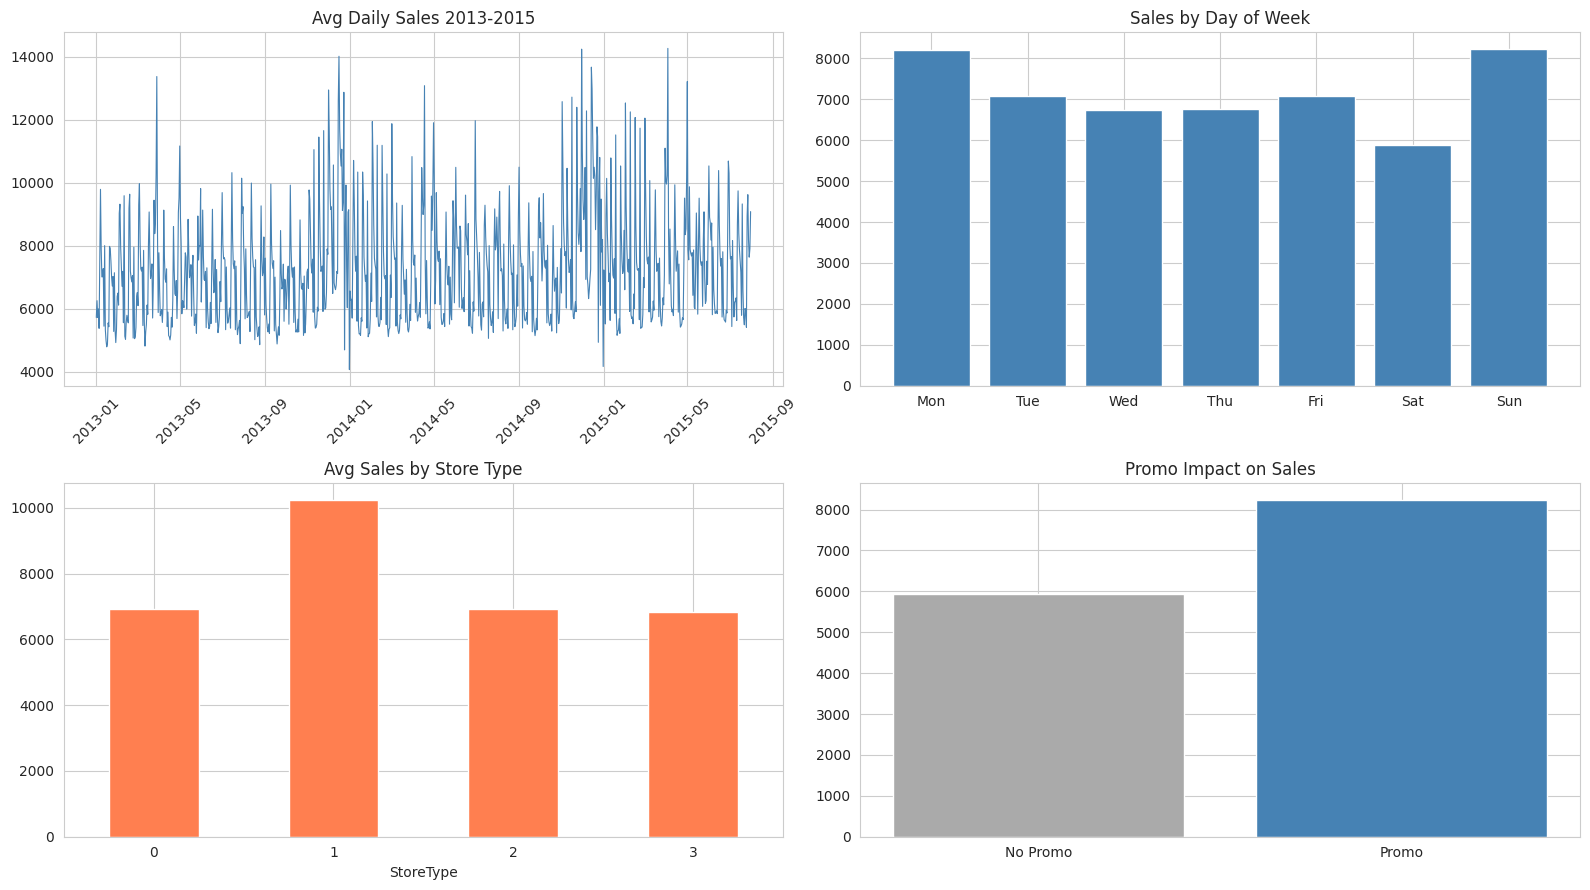

In [7]:
daily = df.groupby('Date')['Sales'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0,0].plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
axes[0,0].set_title('Avg Daily Sales 2013-2015')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)

dow = df.groupby('DayOfWeek')['Sales'].mean()
axes[0,1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values, color='steelblue')
axes[0,1].set_title('Sales by Day of Week')

df.groupby('StoreType')['Sales'].mean().plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Avg Sales by Store Type')
axes[1,0].tick_params(axis='x', rotation=0)

promo = df.groupby('Promo')['Sales'].mean()
axes[1,1].bar(['No Promo', 'Promo'], promo.values, color=['#aaa', 'steelblue'])
axes[1,1].set_title('Promo Impact on Sales')

plt.tight_layout()
plt.show()

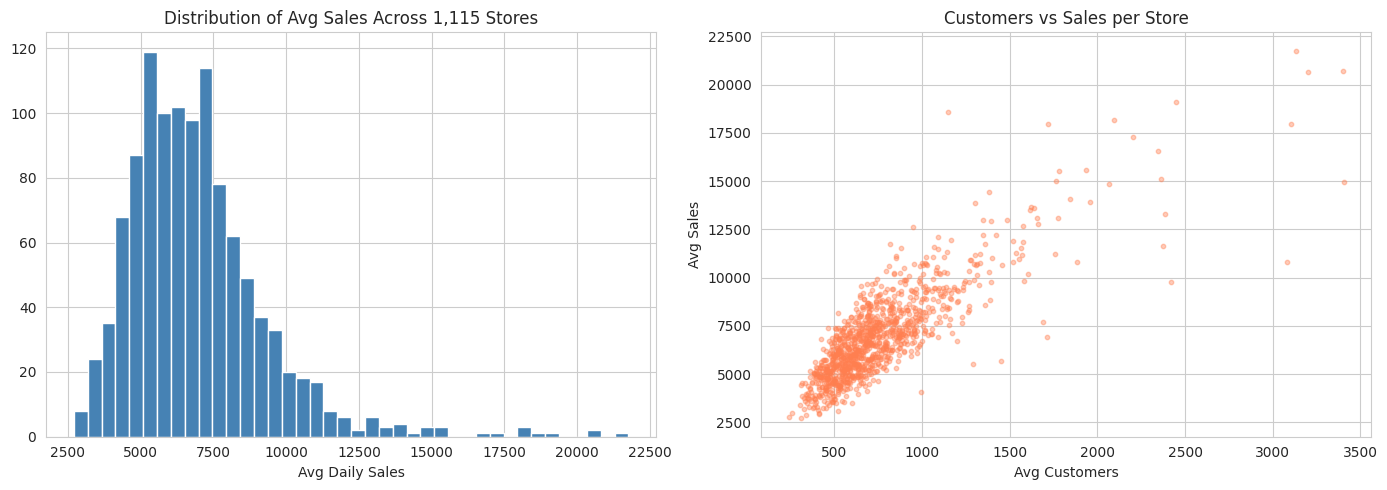

Top 10% of stores drive 17.9% of total sales


In [8]:
store_stats = df.groupby('Store').agg(
    avg_sales=('Sales', 'mean'),
    avg_customers=('Customers', 'mean'),
    total_sales=('Sales', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(store_stats['avg_sales'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Avg Sales Across 1,115 Stores')
axes[0].set_xlabel('Avg Daily Sales')

axes[1].scatter(store_stats['avg_customers'], store_stats['avg_sales'], alpha=0.4, s=10, color='coral')
axes[1].set_title('Customers vs Sales per Store')
axes[1].set_xlabel('Avg Customers')
axes[1].set_ylabel('Avg Sales')

plt.tight_layout()
plt.show()

# just checking how concentrated sales are
top10 = store_stats.nlargest(112, 'total_sales')['total_sales'].sum()
total = store_stats['total_sales'].sum()
print(f'Top 10% of stores drive {top10/total*100:.1f}% of total sales')

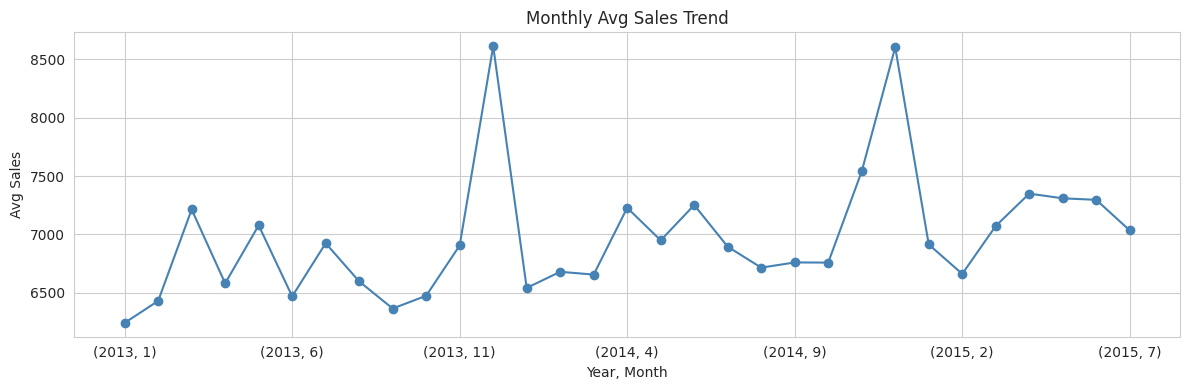

In [9]:
monthly = df.groupby([df['Date'].dt.year, df['Date'].dt.month])['Sales'].mean()
monthly.plot(figsize=(12,4), marker='o', color='steelblue')
plt.title('Monthly Avg Sales Trend')
plt.xlabel('Year, Month')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.show()

### Feature Engineering

In [30]:
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# basic date stuff
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

# lag features - these end up being super important for tree models
for lag in [1, 7, 14, 28]:
    df[f'Sales_lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)

# rolling means
for w in [7, 14, 28]:
    df[f'Sales_roll_mean_{w}'] = df.groupby('Store')['Sales'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean())

df['Sales_roll_std_7'] = df.groupby('Store')['Sales'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).std())

# flag high/low seasonality months
df['IsDecember'] = (df['Month'] == 12).astype(int)
df['IsSummer'] = df['Month'].isin([6, 7, 8]).astype(int)

# how many months has the nearest competitor been open
df['CompetitionOpenMonths'] = (
    12 * (df['Year'] - df['CompetitionOpenSinceYear']) +
    (df['Month'] - df['CompetitionOpenSinceMonth'])
).clip(lower=0)

# is promo2 actually running this month for this store
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['PromoMonth'] = df['Month'].map(month_map)
df['IsPromo2Active'] = df.apply(
    lambda r: 1 if r['Promo2'] == 1 and r['PromoMonth'] in str(r['PromoInterval']) else 0, axis=1)

# store-level avg revenue per customer
spc = df.groupby('Store').apply(lambda x: x['Sales'].sum() / x['Customers'].sum()).rename('SalesPerCustomer')
df = df.merge(spc, on='Store', how='left')

print(f'features: {df.shape[1]} | rows: {df.shape[0]:,}')

features: 41 | rows: 844,338


### Baseline + XGBoost

In [11]:
from sklearn.metrics import mean_squared_error

df_model = df.dropna(subset=['Sales_lag_1', 'Sales_lag_7', 'Sales_roll_mean_7']).copy()

# time-series cross-validation with expanding window
# each fold trains on everything up to that year and validates on the next
# can't do random CV here because future data would leak into training
cv_years = [(2013, 2014), (2014, 2015)]
cv_scores = []

for train_year_end, val_year in cv_years:
    cv_train = df_model[df_model['Year'] <= train_year_end]
    cv_val   = df_model[df_model['Year'] == val_year]
    m = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    feat_cols_cv = [
        'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
        'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2',
        'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter',
        'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
        'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_28',
        'Sales_roll_mean_7', 'Sales_roll_mean_14', 'Sales_roll_mean_28', 'Sales_roll_std_7',
        'IsDecember', 'IsSummer', 'CompetitionOpenMonths', 'IsPromo2Active', 'SalesPerCustomer'
    ]
    m.fit(cv_train[feat_cols_cv], cv_train['Sales'])
    preds_cv = m.predict(cv_val[feat_cols_cv])
    mape_cv = mean_absolute_percentage_error(cv_val['Sales'], preds_cv) * 100
    cv_scores.append(mape_cv)
    print(f'train up to {train_year_end} | val {val_year} | MAPE: {mape_cv:.2f}%')

print(f'avg CV MAPE: {sum(cv_scores)/len(cv_scores):.2f}%')

# final train/test split for the actual model
train_df = df_model[df_model['Year'] < 2015]
test_df  = df_model[df_model['Year'] == 2015]

baseline_preds = test_df['Sales_roll_mean_7']
baseline_mape  = mean_absolute_percentage_error(test_df['Sales'], baseline_preds) * 100
baseline_rmse  = mean_squared_error(test_df['Sales'], baseline_preds) ** 0.5
print(f'\nbaseline MAPE: {baseline_mape:.2f}% | RMSE: {baseline_rmse:.0f}')

train up to 2013 | val 2014 | MAPE: 11.43%
train up to 2014 | val 2015 | MAPE: 10.50%
avg CV MAPE: 10.96%

baseline MAPE: 23.43% | RMSE: 2063


In [12]:
feature_cols = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2',
    'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
    'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_28',
    'Sales_roll_mean_7', 'Sales_roll_mean_14', 'Sales_roll_mean_28', 'Sales_roll_std_7',
    'IsDecember', 'IsSummer', 'CompetitionOpenMonths', 'IsPromo2Active', 'SalesPerCustomer'
]

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(train_df[feature_cols], train_df['Sales'],
        eval_set=[(test_df[feature_cols], test_df['Sales'])], verbose=100)

xgb_preds = xgb.predict(test_df[feature_cols])
xgb_mape  = mean_absolute_percentage_error(test_df['Sales'], xgb_preds) * 100
xgb_rmse  = mean_squared_error(test_df['Sales'], xgb_preds) ** 0.5
improvement = (baseline_mape - xgb_mape) / baseline_mape * 100

print(f'xgboost MAPE: {xgb_mape:.2f}% | RMSE: {xgb_rmse:.0f}')
print(f'baseline MAPE: {baseline_mape:.2f}% | RMSE: {baseline_rmse:.0f}')
print(f'improvement over baseline: {improvement:.1f}%')

[0]	validation_0-rmse:2911.47295
[100]	validation_0-rmse:1036.46907
[200]	validation_0-rmse:992.67924
[300]	validation_0-rmse:976.23913
[400]	validation_0-rmse:968.32645
[499]	validation_0-rmse:961.47818
xgboost MAPE: 10.34% | RMSE: 961
baseline MAPE: 23.43% | RMSE: 2063
improvement over baseline: 55.9%


### ARIMA on a single store

ARIMA MAPE (store 1): 14.19%


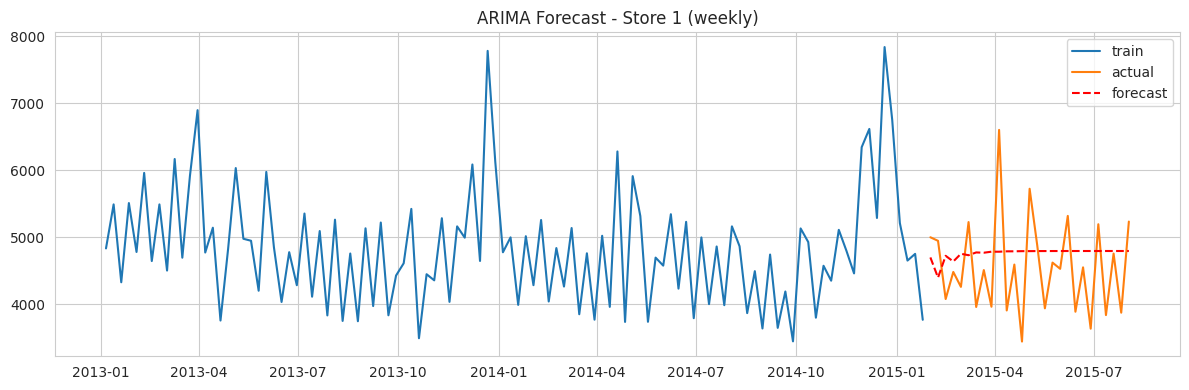

In [13]:
# ARIMA doesn't scale to 1115 stores so just running it on store 1 as a comparison
s1 = df[df['Store'] == 1].set_index('Date').sort_index()
s1_weekly = s1['Sales'].resample('W').mean().dropna()

split = int(len(s1_weekly) * 0.8)
arima_train = s1_weekly.iloc[:split]
arima_test = s1_weekly.iloc[split:]

model = ARIMA(arima_train, order=(2, 1, 2))
fit = model.fit()
preds = fit.forecast(steps=len(arima_test))

arima_mape = mean_absolute_percentage_error(arima_test, preds) * 100
print(f'ARIMA MAPE (store 1): {arima_mape:.2f}%')

plt.figure(figsize=(12, 4))
plt.plot(arima_train.index, arima_train, label='train')
plt.plot(arima_test.index, arima_test, label='actual')
plt.plot(arima_test.index, preds, label='forecast', linestyle='--', color='red')
plt.title('ARIMA Forecast - Store 1 (weekly)')
plt.legend()
plt.tight_layout()
plt.show()

### Results

                  Model  MAPE (%)   RMSE
Baseline (rolling mean)     23.43 2063.0
                XGBoost     10.34  961.0


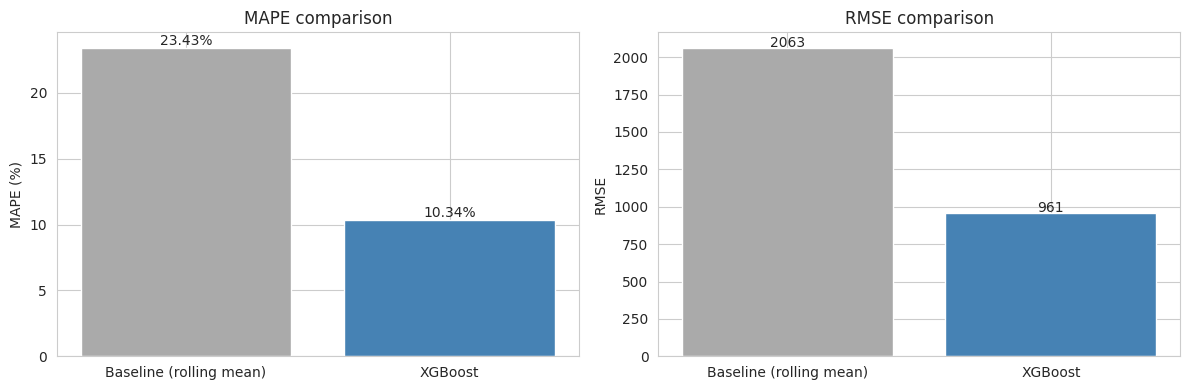

In [14]:
results = pd.DataFrame({
    'Model': ['Baseline (rolling mean)', 'XGBoost'],
    'MAPE (%)': [round(baseline_mape, 2), round(xgb_mape, 2)],
    'RMSE': [round(baseline_rmse, 0), round(xgb_rmse, 0)]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(results['Model'], results['MAPE (%)'], color=['#aaa', 'steelblue'])
for bar, val in zip(bars, results['MAPE (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', fontsize=10)
axes[0].set_title('MAPE comparison')
axes[0].set_ylabel('MAPE (%)')

bars2 = axes[1].bar(results['Model'], results['RMSE'], color=['#aaa', 'steelblue'])
for bar, val in zip(bars2, results['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', fontsize=10)
axes[1].set_title('RMSE comparison')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

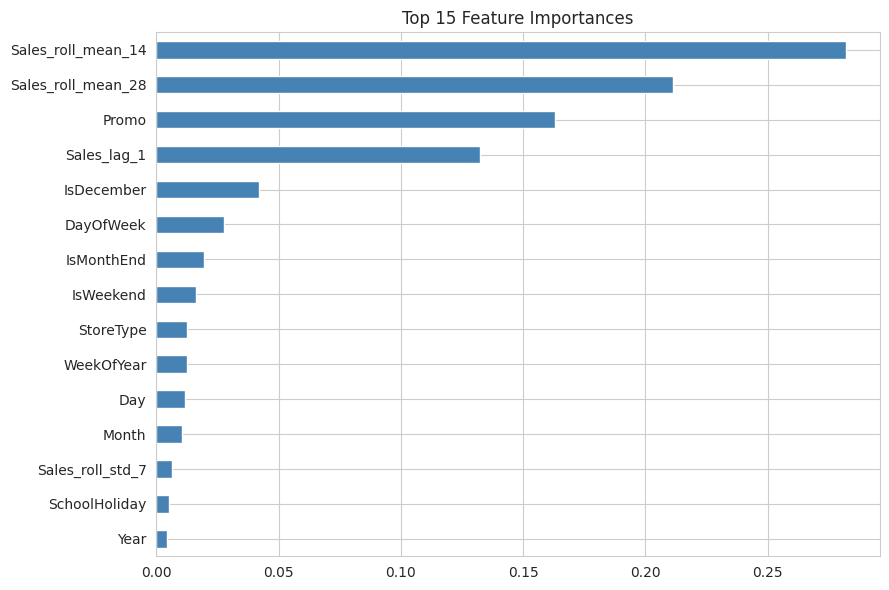

In [15]:
feat_imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [16]:
export = test_df[['Store', 'Date', 'Sales']].copy()
export['xgb_forecast'] = xgb_preds
export['baseline_forecast'] = baseline_preds.values
export['error_pct'] = abs(export['Sales'] - export['xgb_forecast']) / export['Sales'] * 100
export['Month'] = export['Date'].dt.month
export['Year'] = export['Date'].dt.year
export = export.merge(store[['Store', 'StoreType', 'Assortment']], on='Store', how='left')
export.to_csv('/content/forecast_export.csv', index=False)
print(f'{len(export):,} rows exported')
export.head()

196,029 rows exported


,Store,Date,Sales,xgb_forecast,baseline_forecast,error_pct,Month,Year,StoreType,Assortment
0,1,2015-01-02,5509,5678.565430,6077.142857,3.077971,1,2015,c,a
1,1,2015-01-03,5023,4652.975586,5531.142857,7.366602,1,2015,c,a
2,1,2015-01-05,6239,8941.516602,5111.714286,43.316503,1,2015,c,a
3,1,2015-01-06,4574,6133.666992,5480.285714,34.098535,1,2015,c,a
4,1,2015-01-07,4796,6380.615723,5268.428571,33.040361,1,2015,c,a


### Store Segmentation

In [17]:
# build a profile per store to cluster on
store_profile = df.groupby('Store').agg(
    avg_sales=('Sales', 'mean'),
    sales_std=('Sales', 'std'),
    avg_customers=('Customers', 'mean'),
    promo_days=('Promo', 'sum'),
    total_days=('Promo', 'count'),
    avg_sales_per_customer=('Sales', lambda x: x.sum() / df.loc[x.index, 'Customers'].sum())
).reset_index()

store_profile['promo_rate'] = store_profile['promo_days'] / store_profile['total_days']
store_profile['sales_cv'] = store_profile['sales_std'] / store_profile['avg_sales']

yearly = df.groupby(['Store', df['Date'].dt.year])['Sales'].mean().unstack()
yearly.columns = [f'sales_{c}' for c in yearly.columns]
if 'sales_2013' in yearly.columns and 'sales_2015' in yearly.columns:
    yearly['yoy_growth'] = (yearly['sales_2015'] - yearly['sales_2013']) / yearly['sales_2013'] * 100
    store_profile = store_profile.merge(yearly[['yoy_growth']], on='Store', how='left')
    store_profile['yoy_growth'].fillna(0, inplace=True)

print(store_profile.shape)
store_profile.head()

(1115, 10)


,Store,avg_sales,sales_std,avg_customers,promo_days,total_days,avg_sales_per_customer,promo_rate,sales_cv,yoy_growth
0,1,4759.096031,1012.106393,564.049936,350,781,8.437366,0.448143,0.212668,-8.001848
1,2,4953.900510,1610.149102,583.998724,354,784,8.482725,0.451531,0.325027,2.053623
2,3,6942.568678,2193.383804,750.077022,350,779,9.255808,0.449294,0.315933,-2.125992
3,4,9638.401786,1936.031881,1321.752551,353,784,7.292138,0.450255,0.200866,4.862537
4,5,4676.274711,1765.745628,537.340180,351,779,8.702634,0.450578,0.377597,-1.722876


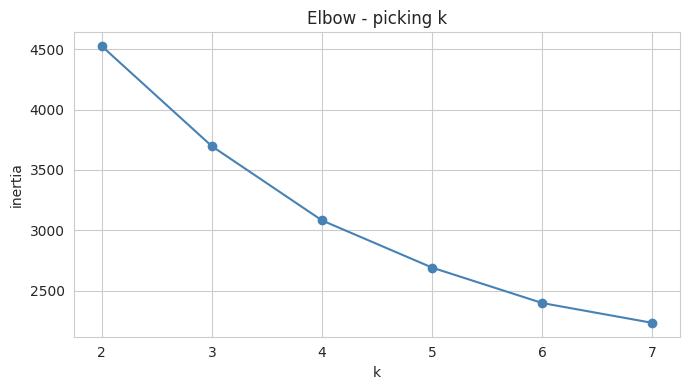

In [18]:
seg_features = ['avg_sales', 'sales_cv', 'promo_rate', 'avg_sales_per_customer', 'yoy_growth']
X_seg = store_profile[seg_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

# elbow to pick k
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 8), inertias, marker='o', color='steelblue')
plt.title('Elbow - picking k')
plt.xlabel('k')
plt.ylabel('inertia')
plt.tight_layout()
plt.show()

In [19]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
store_profile['Segment'] = km.fit_predict(X_scaled)

seg_summary = store_profile.groupby('Segment')[seg_features].mean().round(2)
seg_summary['store_count'] = store_profile.groupby('Segment')['Store'].count()
print(seg_summary)

# assign readable names based on what each cluster looks like
seg_labels = {}
for seg in seg_summary.index:
    avg = seg_summary.loc[seg, 'avg_sales']
    growth = seg_summary.loc[seg, 'yoy_growth']
    promo = seg_summary.loc[seg, 'promo_rate']
    if avg == seg_summary['avg_sales'].max():
        seg_labels[seg] = 'High Volume'
    elif growth == seg_summary['yoy_growth'].max():
        seg_labels[seg] = 'Fast Growing'
    elif promo == seg_summary['promo_rate'].max():
        seg_labels[seg] = 'Promo Dependent'
    else:
        seg_labels[seg] = 'Stable / Low Volume'

store_profile['SegmentLabel'] = store_profile['Segment'].map(seg_labels)
print('\nsegment breakdown:')
print(store_profile['SegmentLabel'].value_counts())

         avg_sales  sales_cv  promo_rate  avg_sales_per_customer  yoy_growth  \
Segment                                                                        
0          5572.33      0.33        0.45                    9.02        3.37   
1          8183.75      0.23        0.45                    8.48        1.09   
2          6820.71      0.25        0.45                   11.86       10.58   
3          8399.94      0.29        0.39                    6.94       10.03   

         store_count  
Segment               
0                358  
1                384  
2                341  
3                 32  

segment breakdown:
SegmentLabel
Promo Dependent    742
Fast Growing       341
High Volume         32
Name: count, dtype: int64


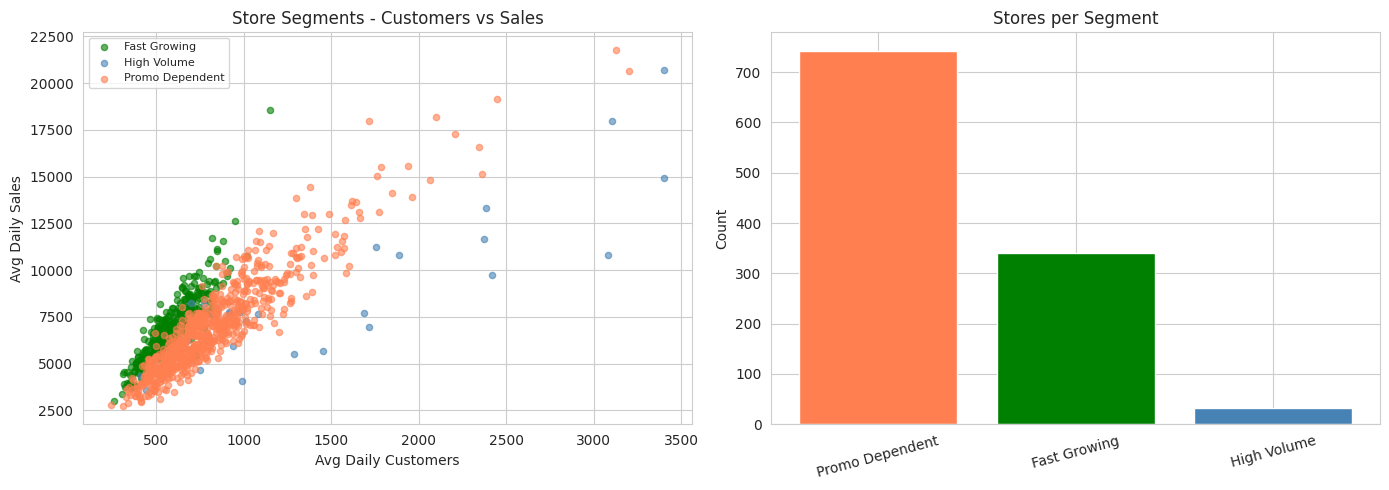

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'High Volume': 'steelblue', 'Fast Growing': 'green',
          'Promo Dependent': 'coral', 'Stable / Low Volume': '#aaa'}

for label, grp in store_profile.groupby('SegmentLabel'):
    axes[0].scatter(grp['avg_customers'], grp['avg_sales'],
                    label=label, alpha=0.6, s=20, color=colors.get(label, 'gray'))
axes[0].set_title('Store Segments - Customers vs Sales')
axes[0].set_xlabel('Avg Daily Customers')
axes[0].set_ylabel('Avg Daily Sales')
axes[0].legend(fontsize=8)

seg_counts = store_profile['SegmentLabel'].value_counts()
axes[1].bar(seg_counts.index, seg_counts.values,
            color=[colors.get(l, 'gray') for l in seg_counts.index])
axes[1].set_title('Stores per Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Promo ROI Analysis

In [21]:
promo_analysis = df.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()
promo_analysis.columns = ['No Promo', 'Promo']
promo_analysis['Lift'] = promo_analysis['Promo'] - promo_analysis['No Promo']
promo_analysis['Lift_%'] = (promo_analysis['Lift'] / promo_analysis['No Promo'] * 100).round(1)
print(promo_analysis)

              No Promo         Promo         Lift  Lift_%
StoreType                                                
0          5809.052116   8304.548971  2495.496855    43.0
1          9567.855955  11311.802796  1743.946840    18.2
2          6028.547554   8042.788106  2014.240553    33.4
3          5855.391063   8018.036562  2162.645499    36.9


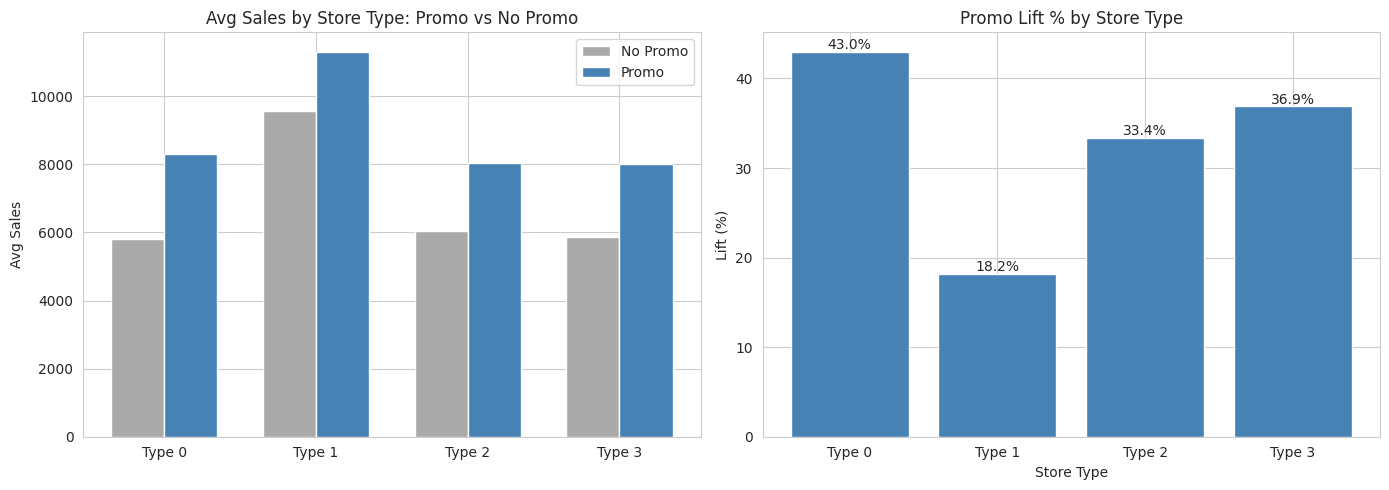

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(promo_analysis))
w = 0.35
axes[0].bar(x - w/2, promo_analysis['No Promo'], w, label='No Promo', color='#aaa')
axes[0].bar(x + w/2, promo_analysis['Promo'], w, label='Promo', color='steelblue')
axes[0].set_title('Avg Sales by Store Type: Promo vs No Promo')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Type {i}' for i in promo_analysis.index])
axes[0].set_ylabel('Avg Sales')
axes[0].legend()

bars = axes[1].bar(promo_analysis.index, promo_analysis['Lift_%'],
                   color=['steelblue' if v > 0 else 'coral' for v in promo_analysis['Lift_%']])
for bar, val in zip(bars, promo_analysis['Lift_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Promo Lift % by Store Type')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Lift (%)')
axes[1].set_xticks(promo_analysis.index)
axes[1].set_xticklabels([f'Type {i}' for i in promo_analysis.index])

plt.tight_layout()
plt.show()

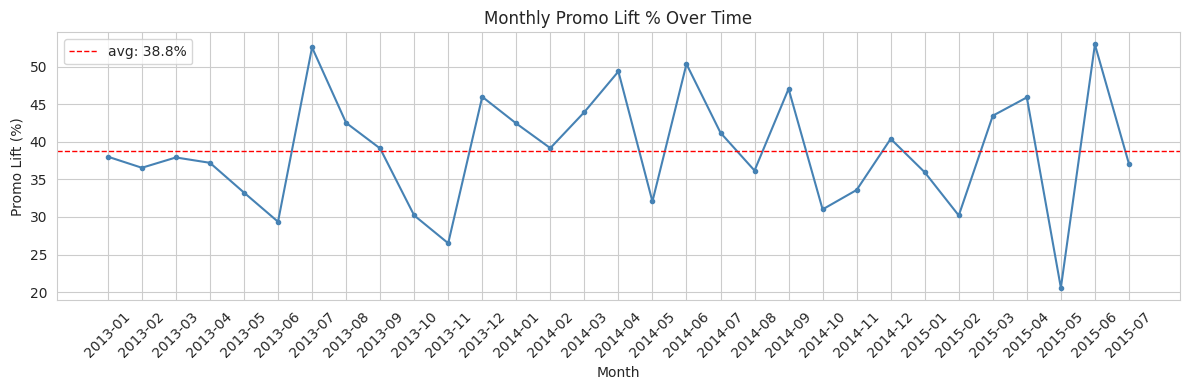

avg promo lift: 32.9%


In [23]:
# checking if promo lift is declining over time
monthly_promo = df.groupby([df['Date'].dt.to_period('M'), 'Promo'])['Sales'].mean().unstack()
monthly_promo.columns = ['No Promo', 'Promo']
monthly_promo['Lift_%'] = (monthly_promo['Promo'] - monthly_promo['No Promo']) / monthly_promo['No Promo'] * 100
monthly_promo = monthly_promo.dropna()

plt.figure(figsize=(12, 4))
plt.plot(monthly_promo.index.astype(str), monthly_promo['Lift_%'],
         color='steelblue', marker='o', markersize=3)
plt.axhline(monthly_promo['Lift_%'].mean(), color='red', linestyle='--', linewidth=1,
            label=f'avg: {monthly_promo["Lift_%"].mean():.1f}%')
plt.title('Monthly Promo Lift % Over Time')
plt.xlabel('Month')
plt.ylabel('Promo Lift (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(f'avg promo lift: {promo_analysis["Lift_%"].mean():.1f}%')

### Seasonality Decomposition

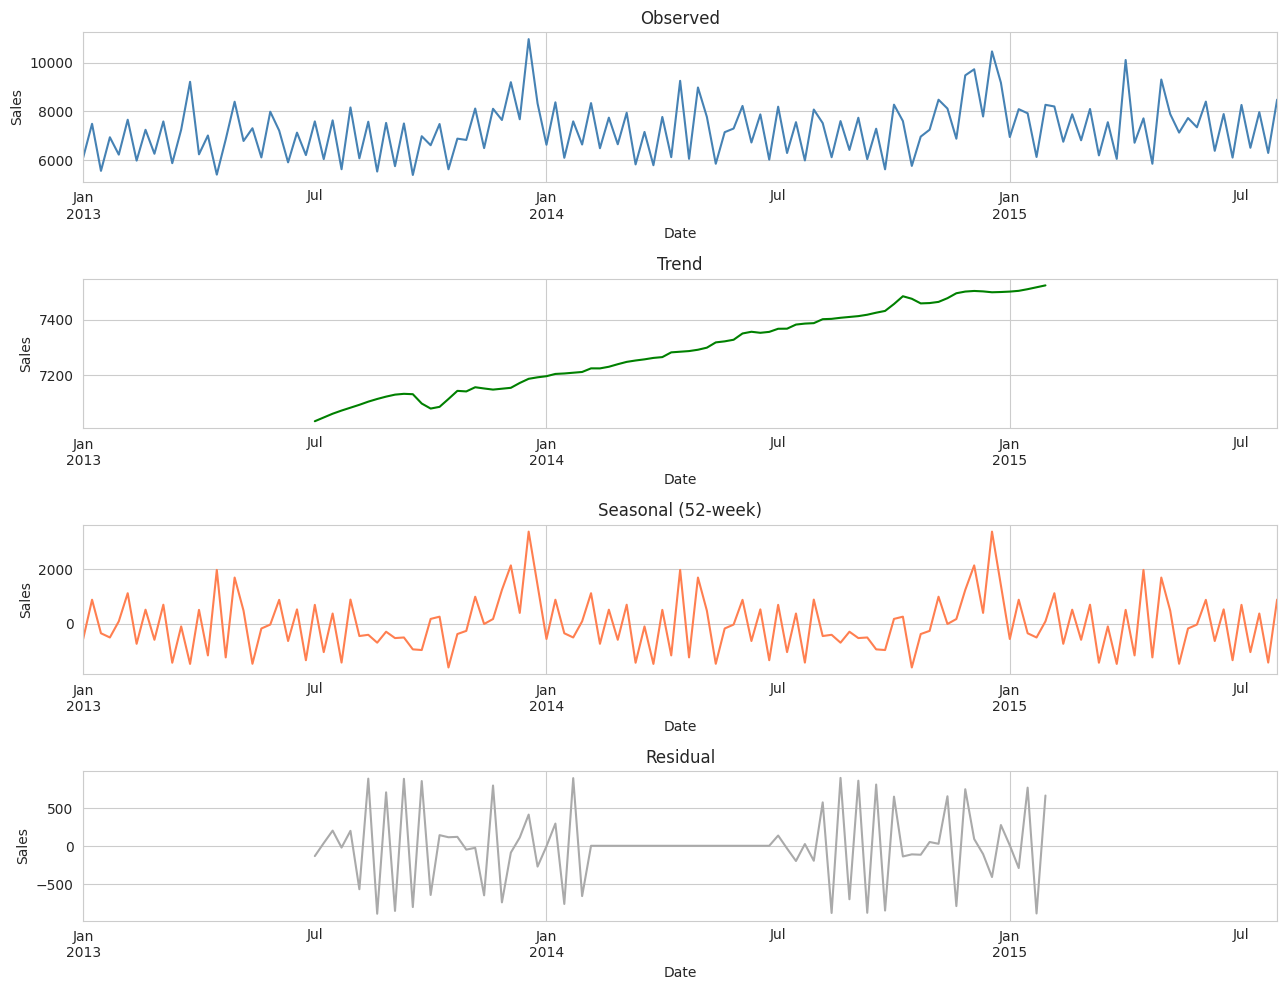

In [24]:
weekly_avg = df.groupby('Date')['Sales'].mean().resample('W').mean().dropna()
decomp = seasonal_decompose(weekly_avg, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
decomp.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Sales')

decomp.trend.plot(ax=axes[1], color='green')
axes[1].set_title('Trend')
axes[1].set_ylabel('Sales')

decomp.seasonal.plot(ax=axes[2], color='coral')
axes[2].set_title('Seasonal (52-week)')
axes[2].set_ylabel('Sales')

decomp.resid.plot(ax=axes[3], color='#aaa')
axes[3].set_title('Residual')
axes[3].set_ylabel('Sales')

plt.tight_layout()
plt.show()

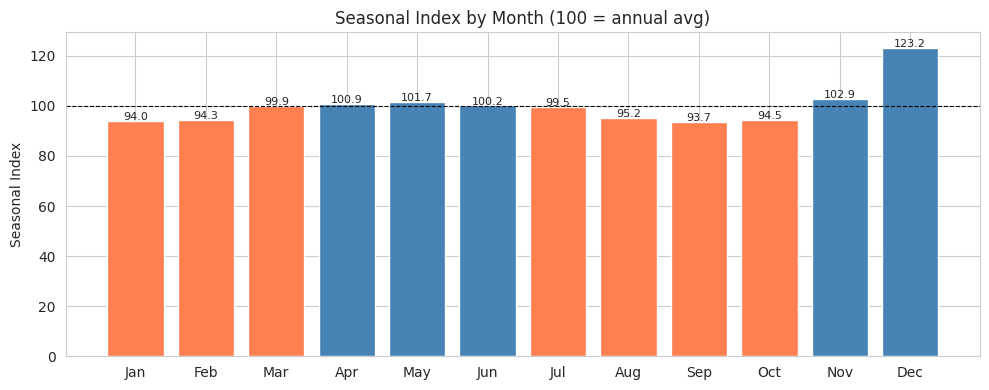

strong months (>105): ['Dec']
weak months (<95): ['Jan', 'Feb', 'Sep', 'Oct']


In [25]:
# seasonal index - how much does each month over/underperform vs the annual avg
monthly_avg = df.groupby(df['Date'].dt.month)['Sales'].mean()
seasonal_index = (monthly_avg / monthly_avg.mean() * 100).round(1)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_si = ['steelblue' if v >= 100 else 'coral' for v in seasonal_index.values]

plt.figure(figsize=(10, 4))
bars = plt.bar(month_names, seasonal_index.values, color=colors_si)
plt.axhline(100, color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, seasonal_index.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontsize=8)
plt.title('Seasonal Index by Month (100 = annual avg)')
plt.ylabel('Seasonal Index')
plt.tight_layout()
plt.show()

print('strong months (>105):', [month_names[i-1] for i in seasonal_index[seasonal_index > 105].index])
print('weak months (<95):', [month_names[i-1] for i in seasonal_index[seasonal_index < 95].index])

### Forecast Accuracy by Segment

In [26]:
test_results = test_df[['Store', 'Date', 'Sales']].copy()
test_results['xgb_forecast'] = xgb_preds
test_results['error_pct'] = abs(test_results['Sales'] - test_results['xgb_forecast']) / test_results['Sales'] * 100
test_results = test_results.merge(store_profile[['Store', 'SegmentLabel']], on='Store', how='left')
test_results = test_results.merge(store[['Store', 'StoreType']], on='Store', how='left')

seg_mape = test_results.groupby('SegmentLabel').agg(
    mape=('error_pct', 'mean'),
    store_count=('Store', 'nunique'),
    avg_actual_sales=('Sales', 'mean')
).round(2).sort_values('mape')

print('MAPE by segment:')
print(seg_mape)

MAPE by segment:
                  mape  store_count  avg_actual_sales
SegmentLabel                                         
Fast Growing      9.81          341           7171.77
Promo Dependent  10.49          742           6962.06
High Volume      12.18           32           8817.77


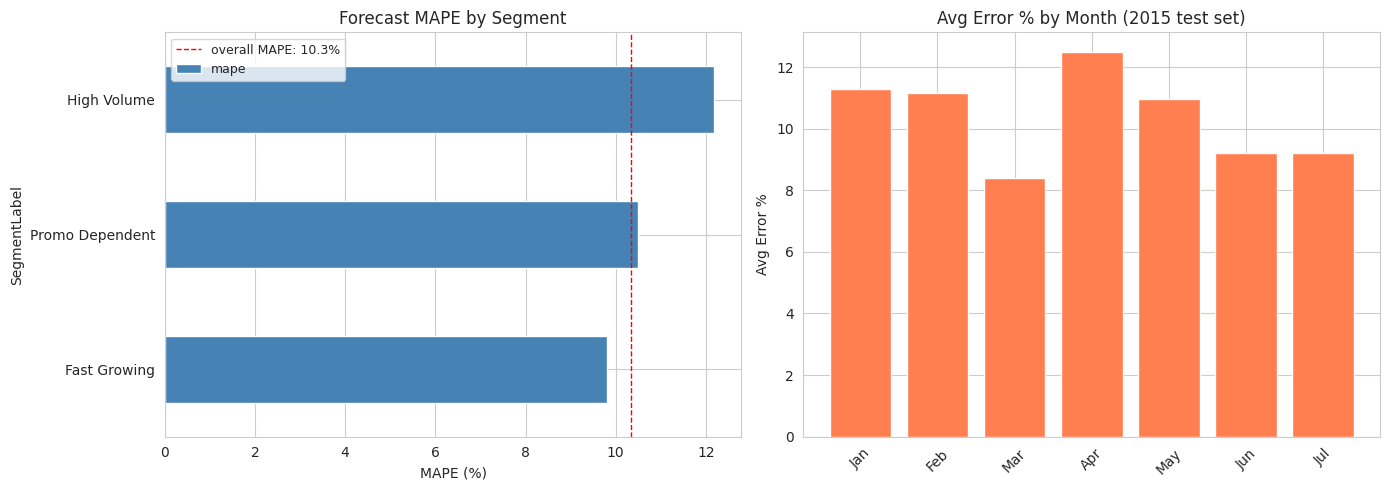

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_mape['mape'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(xgb_mape, color='red', linestyle='--', linewidth=1,
                label=f'overall MAPE: {xgb_mape:.1f}%')
axes[0].set_title('Forecast MAPE by Segment')
axes[0].set_xlabel('MAPE (%)')
axes[0].legend(fontsize=9)

test_results['Month'] = pd.to_datetime(test_results['Date']).dt.month
monthly_error = test_results.groupby('Month')['error_pct'].mean()
axes[1].bar(month_names[:len(monthly_error)], monthly_error.values, color='coral')
axes[1].set_title('Avg Error % by Month (2015 test set)')
axes[1].set_ylabel('Avg Error %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [28]:
summary = store_profile.groupby('SegmentLabel').agg(
    num_stores=('Store', 'count'),
    avg_daily_sales=('avg_sales', 'mean'),
    avg_promo_rate=('promo_rate', 'mean'),
    avg_yoy_growth=('yoy_growth', 'mean')
).round(2)

summary['avg_daily_sales'] = summary['avg_daily_sales'].map('${:,.0f}'.format)
summary['avg_promo_rate'] = (summary['avg_promo_rate'] * 100).map('{:.1f}%'.format)
summary['avg_yoy_growth'] = summary['avg_yoy_growth'].map('{:.1f}%'.format)

print(summary.to_string())
print()
print('High Volume: stock availability matters more than promos')
print('Fast Growing: ramp up inventory ahead of peak periods')
print('Promo Dependent: worth checking if promo ROI still holds')
print('Stable / Low Volume: review operational costs')

                 num_stores avg_daily_sales avg_promo_rate avg_yoy_growth
SegmentLabel                                                             
Fast Growing            341          $6,821          45.0%          10.6%
High Volume              32          $8,400          39.0%          10.0%
Promo Dependent         742          $6,924          45.0%           2.2%

High Volume: stock availability matters more than promos
Fast Growing: ramp up inventory ahead of peak periods
Promo Dependent: worth checking if promo ROI still holds
Stable / Low Volume: review operational costs


### Key Findings

**Model performance**  
XGBoost finished at 10.34% MAPE and RMSE 961, down from the baseline's 23.43% MAPE and RMSE 2063 — roughly a 56% error reduction. The two CV folds held up consistently: 11.43% on 2013→2014 and 10.50% on 2013+2014→2015, so there's no sign of overfitting to one particular year. ARIMA on Store 1 came in at 14.19% — fine for a single univariate series but it doesn't have access to any of the cross-store or promo context that XGBoost uses, which explains most of the gap.

**What actually drove predictions**  
The two rolling mean features dominated by a wide margin — Sales_roll_mean_14 was the top feature at ~0.28 importance, Sales_roll_mean_28 second at ~0.21, then Promo at ~0.16, and Sales_lag_1 at ~0.13. Everything else (IsDecember, DayOfWeek, StoreType, calendar features) was well below 0.05. The model is essentially anchoring on recent demand history and then using promo status as the main adjustment factor. That makes intuitive sense — if a store has been averaging 7,000 in sales over the past two weeks, that's a much stronger signal than what month it is.

**Promos**  
Average promo lift across store types is 32.9% but the chart tells a more interesting story. Type 0 sees 43% lift (from ~5,800 to ~8,300), Types 2 and 3 are around 33-37%, but Type 1 only sees 18.2% despite already having the highest baseline sales (~9,500). The monthly promo lift chart has an avg line sitting around 38-39% and the lift is fairly stable over time — no real sign of promo fatigue across the 2013-2015 window. Still, Type 1 stores are doing a lot of promo days for relatively low incremental return compared to the others.

**Seasonality**  
December is the standout at 123.2 — nearly 25% above the annual average. November is mildly above average at 102.9. Everything else is either near 100 or below. The weakest months are Sep (93.7) and Oct (94.5), which creates an interesting mid-autumn trough right before the December peak. Jan and Feb are also weak at 94.0 and 94.3. The decomposition trend chart confirms there's genuine upward growth across the whole period from ~7,100 in early 2013 to ~7,500 by mid-2015, so the business was growing even outside the seasonal swings.

**Store segments**  
Three clusters came out: Promo Dependent (742 stores, 66% of all stores), Fast Growing (341 stores), and High Volume (just 32 stores). The scatter plot shows the Promo Dependent group covers most of the mid-range — roughly 500-1500 avg customers and 5,000-10,000 avg sales. Fast Growing stores overlap heavily with Promo Dependent in customer count but have 10.6% YoY growth vs only 2.2% for Promo Dependent, which is the main thing separating them. High Volume stores are the handful of outliers in the top-right of the scatter — high customer counts, high sales, and they're visually distinct from the rest.

**Forecast accuracy by segment**  
Fast Growing was the easiest to forecast at 9.81% MAPE, Promo Dependent at 10.49%, and High Volume the hardest at 12.18%. The error by month chart (2015 test set only runs Jan-Jul) shows April was the worst month at ~12.5% — likely Easter falling in April that year. March was actually the best at ~8.5%, and the summer months Jun-Jul settled around 9.2%. High Volume stores having worse accuracy despite being the most important revenue-wise is worth noting — those 32 stores probably have more irregular demand driven by local factors the features can't capture.

